In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv('/content/data/CO2 Emissions_Canada.csv')
display(df.head())

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
0,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7385 entries, 0 to 7384
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Make                              7385 non-null   object 
 1   Model                             7385 non-null   object 
 2   Vehicle Class                     7385 non-null   object 
 3   Engine Size(L)                    7385 non-null   float64
 4   Cylinders                         7385 non-null   int64  
 5   Transmission                      7385 non-null   object 
 6   Fuel Type                         7385 non-null   object 
 7   Fuel Consumption City (L/100 km)  7385 non-null   float64
 8   Fuel Consumption Hwy (L/100 km)   7385 non-null   float64
 9   Fuel Consumption Comb (L/100 km)  7385 non-null   float64
 10  Fuel Consumption Comb (mpg)       7385 non-null   int64  
 11  CO2 Emissions(g/km)               7385 non-null   int64  
dtypes: flo

In [6]:
df.describe()

,Engine Size(L),Cylinders,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
count,7385.000000,7385.000000,7385.000000,7385.000000,7385.000000,7385.000000,7385.000000
mean,3.160068,5.615030,12.556534,9.041706,10.975071,27.481652,250.584699
std,1.354170,1.828307,3.500274,2.224456,2.892506,7.231879,58.512679
min,0.900000,3.000000,4.200000,4.000000,4.100000,11.000000,96.000000
25%,2.000000,4.000000,10.100000,7.500000,8.900000,22.000000,208.000000
50%,3.000000,6.000000,12.100000,8.700000,10.600000,27.000000,246.000000
75%,3.700000,6.000000,14.600000,10.200000,12.600000,32.000000,288.000000
max,8.400000,16.000000,30.600000,20.600000,26.100000,69.000000,522.000000


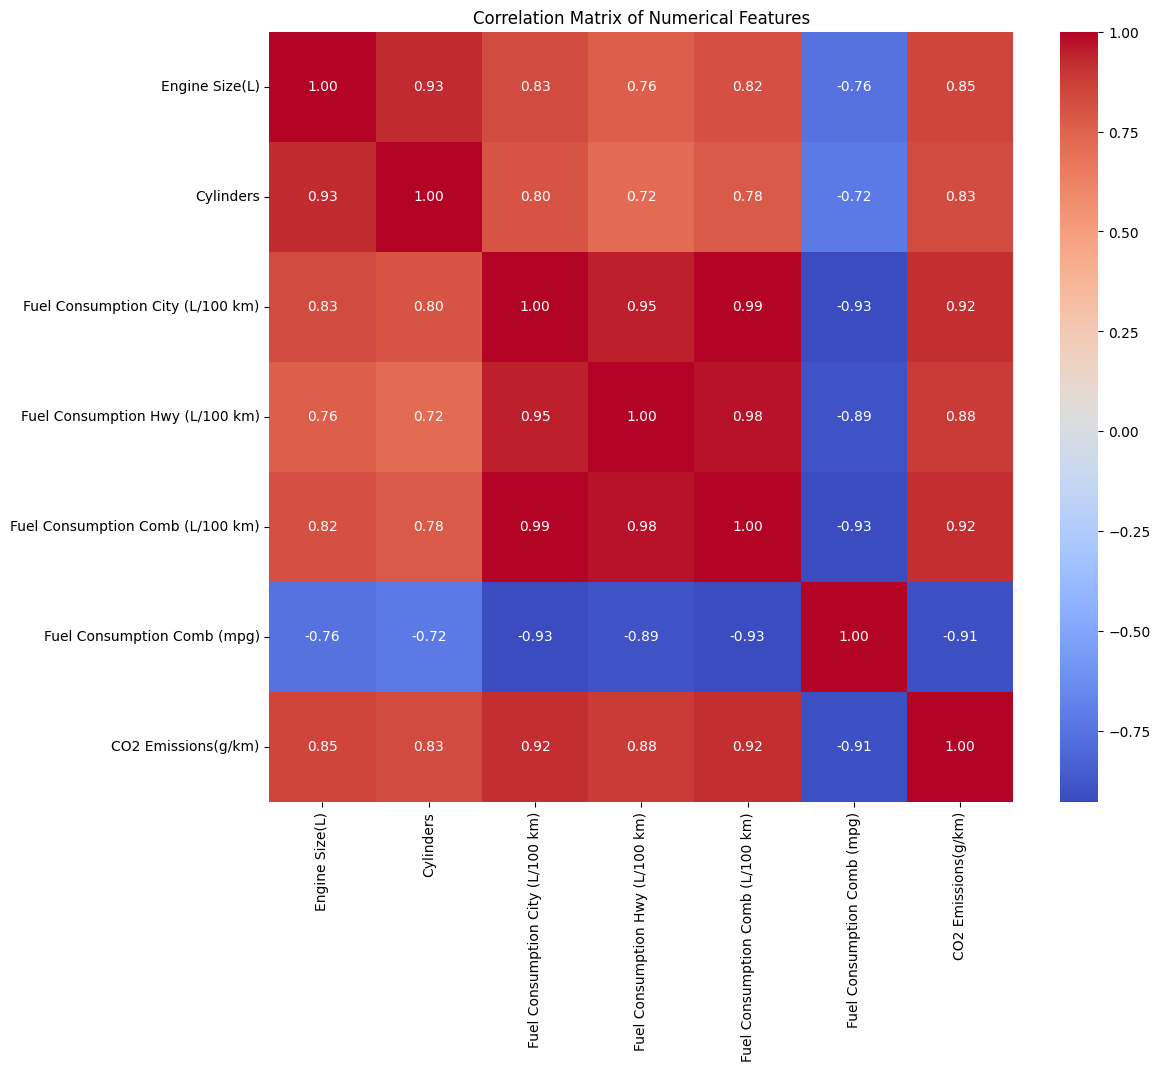

In [9]:
import seaborn as sns
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

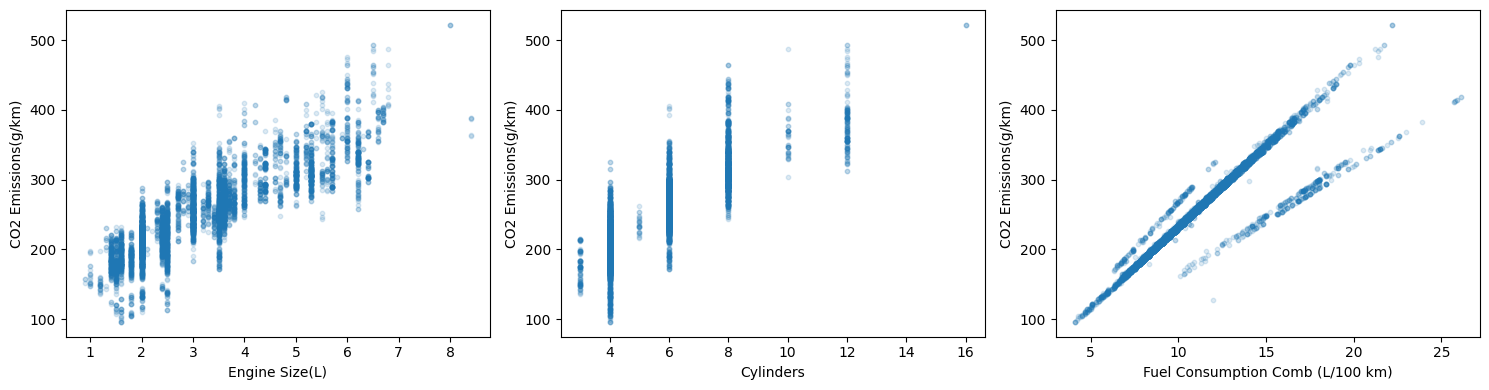

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
features = ['Engine Size(L)', 'Cylinders', 'Fuel Consumption Comb (L/100 km)']

for ax, feat in zip(axes, features):
    ax.scatter(df[feat], df['CO2 Emissions(g/km)'], alpha=0.15, s=10)
    ax.set_xlabel(feat)
    ax.set_ylabel('CO2 Emissions(g/km)')

plt.tight_layout()
plt.show()

In [20]:
cols = ['Engine Size(L)', 'Cylinders', 'Fuel Consumption Comb (L/100 km)', 'CO2 Emissions(g/km)']
data = df[cols].copy()
data.columns = ['engine_size', 'cylinders', 'fuel_comb', 'co2']
data.head()

,engine_size,cylinders,fuel_comb,co2
0,2.0,4,8.5,196
1,2.4,4,9.6,221
2,1.5,4,5.9,136
3,3.5,6,11.1,255
4,3.5,6,10.6,244


In [21]:
print(data.shape)      # should be (7385, 4)
data.describe()

(7385, 4)


,engine_size,cylinders,fuel_comb,co2
count,7385.000000,7385.000000,7385.000000,7385.000000
mean,3.160068,5.615030,10.975071,250.584699
std,1.354170,1.828307,2.892506,58.512679
min,0.900000,3.000000,4.100000,96.000000
25%,2.000000,4.000000,8.900000,208.000000
50%,3.000000,6.000000,10.600000,246.000000
75%,3.700000,6.000000,12.600000,288.000000
max,8.400000,16.000000,26.100000,522.000000


# **We create a Train set,Test Set and Validate Set text**

In [22]:
from sklearn.model_selection import train_test_split

X = data[['engine_size', 'cylinders', 'fuel_comb']].values
y = data['co2'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape)  # expect ~(5908, 3) (1477, 3)

(5908, 3) (1477, 3)


# ***WE Calculate the Scaling using the Equation***
$$z = \frac{x - \mu}{\sigma}$$

In [23]:
def compute_scaling_params(X):
    """Compute mean and std per column — from TRAINING data only."""
    mu = X.mean(axis=0)      # mean of each column
    sigma = X.std(axis=0)    # std of each column
    return mu, sigma

def scale_features(X, mu, sigma):
    """Apply standardization using given mu/sigma."""
    return (X - mu) / sigma

# Compute stats from training data ONLY
mu, sigma = compute_scaling_params(X_train)
print("mu:", mu)
print("sigma:", sigma)

# Apply the SAME mu/sigma to both train and test
X_train_scaled = scale_features(X_train, mu, sigma)
X_test_scaled = scale_features(X_test, mu, sigma)

mu: [ 3.16514895  5.62339201 10.98840555]
sigma: [1.35932386 1.83405345 2.88842259]


In [24]:
print("Train mean (should be ~0):", X_train_scaled.mean(axis=0))
print("Train std (should be ~1):", X_train_scaled.std(axis=0))

print("\nTest mean (won't be exactly 0 — that's expected):", X_test_scaled.mean(axis=0))
print("Test std (won't be exactly 1 — that's expected):", X_test_scaled.std(axis=0))

Train mean (should be ~0): [ 5.72465794e-15 -1.52928148e-16  4.51221660e-15]
Train std (should be ~1): [1. 1. 1.]

Test mean (won't be exactly 0 — that's expected): [-0.01869034 -0.02279526 -0.0230826 ]
Test std (won't be exactly 1 — that's expected): [0.98041262 0.9836798  1.00650037]


In [25]:
def add_bias_column(X):
    """Prepend a column of 1s to X, turning it into the design matrix."""
    m = X.shape[0]  # number of rows
    ones = np.ones((m, 1))
    return np.hstack([ones, X])

X_train_design = add_bias_column(X_train_scaled)
X_test_design = add_bias_column(X_test_scaled)

print(X_train_design.shape)  # should be (5908, 4) — one extra column vs X_train_scaled
print(X_train_design[:3])    # first column should be all 1.0

(5908, 4)
[[ 1.         -0.12149345  0.20534188 -0.37681659]
 [ 1.          0.6141664   0.20534188  0.59257065]
 [ 1.         -0.12149345  0.20534188  0.24636092]]


In [26]:
print("Before (scaled, 3 cols):", X_train_scaled[0])
print("After (design matrix, 4 cols):", X_train_design[0])

Before (scaled, 3 cols): [-0.12149345  0.20534188 -0.37681659]
After (design matrix, 4 cols): [ 1.         -0.12149345  0.20534188 -0.37681659]


# **Gradient Decent**
$$\theta_j := \theta_j - \alpha \frac{\partial}{\partial \theta_j} J(\theta)$$

In [34]:
def gradient_descent(X, y, theta, alpha, iterations):
    m = len(y)
    cost_history = []

    for i in range(iterations):
        predictions = X @ theta
        errors = predictions - y
        gradient = (1 / m) * (X.T @ errors)
        theta = theta - alpha * gradient

        cost_history.append(compute_cost(X, y, theta))

    return theta, cost_history

In [35]:
theta_init = np.zeros(4)
alpha = 0.1
iterations = 500

theta_final, cost_history = gradient_descent(X_train_design, y_train, theta_init, alpha, iterations)

print("Final theta:", theta_final)
print("Final cost:", cost_history[-1])
print("Initial cost:", cost_history[0])

Final theta: [250.93957346   7.73549498  11.58748553  38.31264092]
Final cost: 205.7362531493112
Initial cost: 26542.302729930227


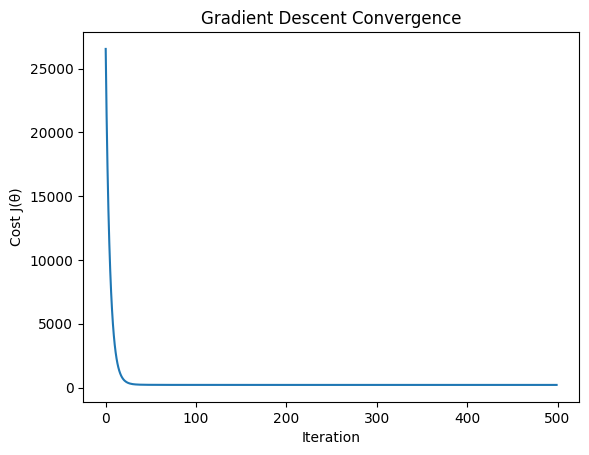

In [36]:
plt.plot(cost_history)
plt.xlabel('Iteration')
plt.ylabel('Cost J(θ)')
plt.title('Gradient Descent Convergence')
plt.show()

# **The Cost Function**
$$J(w, b) = \frac{1}{2m} \sum_{i=1}^{m} (f_{w,b}(x^{(i)}) - y^{(i)})^2$$

In [37]:
def compute_cost(X, y, theta):
    """Mean squared error cost, vectorized — no loops."""
    m = len(y)
    predictions = X @ theta          # X @ theta = matrix-vector product, gives predictions for every row at once
    errors = predictions - y
    cost = (1 / (2 * m)) * (errors @ errors)   # errors @ errors = sum of squared errors
    return cost

In [38]:
theta_test = np.zeros(4)
cost = compute_cost(X_train_design, y_train, theta_test)
print(cost)

33194.61027420447


In [39]:
def normal_equation(X, y):
    return np.linalg.inv(X.T @ X) @ X.T @ y

theta_normal = normal_equation(X_train_design, y_train)
print("Normal equation theta:", theta_normal)


Normal equation theta: [250.93957346   7.60502667  11.70272471  38.3303208 ]


In [40]:
cost_gd = compute_cost(X_train_design, y_train, theta_final)
print("Cost with gradient descent theta:", cost_gd)

Cost with gradient descent theta: 205.7362531493112


In [41]:
def r_squared(X, y, theta):
    predictions = X @ theta
    ss_res = np.sum((y - predictions) ** 2)      # residual sum of squares (your model's errors)
    ss_tot = np.sum((y - y.mean()) ** 2)          # total sum of squares (baseline: always guess the mean)
    return 1 - (ss_res / ss_tot)

train_r2 = r_squared(X_train_design, y_train, theta_final)
test_r2 = r_squared(X_test_design, y_test, theta_final)

print("Train R²:", train_r2)
print("Test R²:", test_r2)

Train R²: 0.8796354058022114
Test R²: 0.8773263106312754


In [42]:
def predict_emissions(engine_size, cylinders, fuel_comb, theta, mu, sigma):
    raw = np.array([engine_size, cylinders, fuel_comb])
    scaled = (raw - mu) / sigma                    # same scaling as training
    x_input = np.insert(scaled, 0, 1.0)             # bias column
    return x_input @ theta

# Try it on a made-up car
pred = predict_emissions(2.0, 4, 8.5, theta_final, mu, sigma)
print(f"Predicted CO2: {pred:.1f} g/km")

Predicted CO2: 201.0 g/km


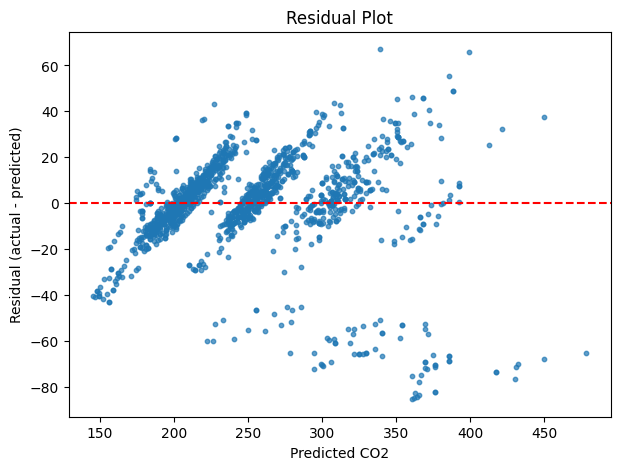

In [46]:
predictions_test = X_test_design @ theta_final
residuals = y_test - predictions_test

plt.figure(figsize=(7,5))
plt.scatter(predictions_test, residuals, alpha=0.7, s=10)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted CO2')
plt.ylabel('Residual (actual - predicted)')
plt.title('Residual Plot')
plt.show()

In [44]:
print(predict_emissions(1.5, 4, 6.0, theta_final, mu, sigma))   # small, efficient car
print(predict_emissions(5.0, 8, 15.0, theta_final, mu, sigma))  # big V8
print(predict_emissions(2.0, 4, 8.5, theta_final, mu, sigma))   # mid-size

165.03993406630127
329.6071009857637
201.04580311806848


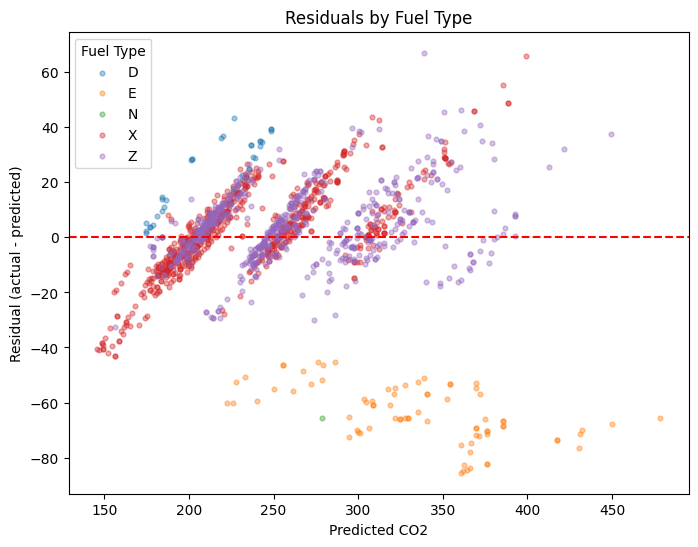

In [47]:
# Bring fuel type back in just to visualize (not to retrain)
test_indices = np.arange(len(df))
_, test_idx = train_test_split(test_indices, test_size=0.2, random_state=42)
fuel_types_test = df.iloc[test_idx]['Fuel Type'].values

predictions_test = X_test_design @ theta_final
residuals = y_test - predictions_test

plt.figure(figsize=(8,6))
for ft in np.unique(fuel_types_test):
    mask = fuel_types_test == ft
    plt.scatter(predictions_test[mask], residuals[mask], alpha=0.4, s=12, label=ft)

plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted CO2')
plt.ylabel('Residual (actual - predicted)')
plt.title('Residuals by Fuel Type')
plt.legend(title='Fuel Type')
plt.show()